<a href="https://colab.research.google.com/github/N1khil-J4dhav/AML-Experiments/blob/main/AML_Experiment_10_Nikhil_Jadhav_35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Data loaded successfully!
Cleaning data...

--- Top 10 Product Associations found ---
                                          antecedents  \
3                          (ALARM CLOCK BAKELIKE RED)   
2                        (ALARM CLOCK BAKELIKE GREEN)   
5                          (ALARM CLOCK BAKELIKE RED)   
4                         (ALARM CLOCK BAKELIKE PINK)   
23                    (SET/6 RED SPOTTY PAPER PLATES)   
22  (SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...   
1                        (ALARM CLOCK BAKELIKE GREEN)   
0                         (ALARM CLOCK BAKELIKE PINK)   
20  (SET/6 RED SPOTTY PAPER PLATES, SET/20 RED RET...   
25                      (SET/6 RED SPOTTY PAPER CUPS)   

                                          consequents   support  confidence  \
3                        (ALARM CLOCK BAKELIKE GREEN)  0.079082    0.837838   
2                          (ALARM CLOCK BAKELIKE RED)  0.079082    0.815789   
5                         (ALARM CLOCK BAKELIKE

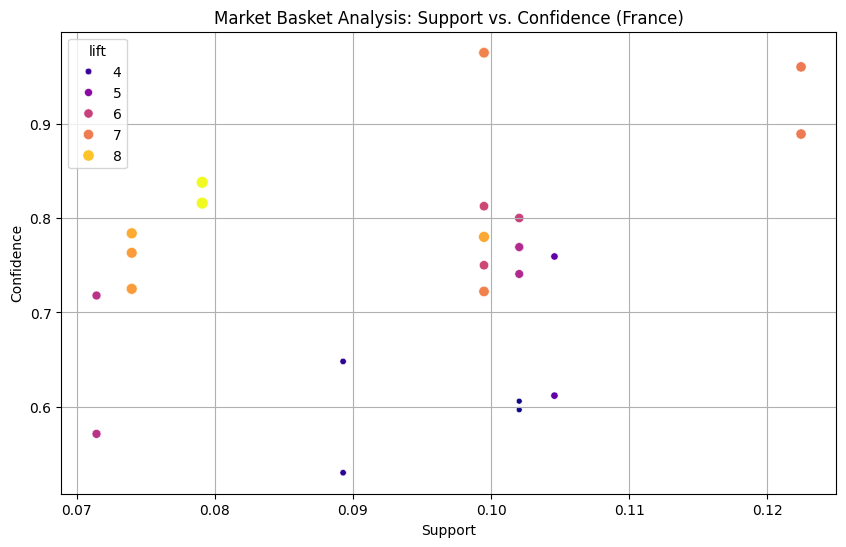

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import warnings

# 1. Setup
warnings.filterwarnings("ignore")

# 2. Load the Dataset
# Using the stable UCI mirror for the Online Retail dataset used in that repo
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("Downloading dataset (this may take a minute due to file size)...")
try:
    # Note: This is an Excel file, so we use read_excel
    df = pd.read_excel(url)
    print("✓ Data loaded successfully!")

    # 3. Data Cleaning (Per the Kuzi Rusere workflow)
    print("Cleaning data...")
    df['Description'] = df['Description'].str.strip()
    df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)
    df['InvoiceNo'] = df['InvoiceNo'].astype('str')

    # Remove credit/cancelled transactions
    df = df[~df['InvoiceNo'].str.contains('C')]

    # 4. Create the Basket
    # Filtering for France to keep the matrix size manageable for Colab RAM
    basket = (df[df['Country'] =="France"]
              .groupby(['InvoiceNo', 'Description'])['Quantity']
              .sum().unstack().reset_index().fillna(0)
              .set_index('InvoiceNo'))

    # 5. One-Hot Encoding
    def encode_units(x):
        if x <= 0: return 0
        if x >= 1: return 1

    basket_sets = basket.applymap(encode_units)

    # Remove 'POSTAGE' as it's not a real product
    if 'POSTAGE' in basket_sets.columns:
        basket_sets.drop('POSTAGE', inplace=True, axis=1)

    # 6. Apply Apriori
    # min_support=0.07 is a common threshold for this dataset
    frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

    # 7. Generate Association Rules
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
    rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

    # 8. Display Results
    print("\n--- Top 10 Product Associations found ---")
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

    # 9. Visualization: Support vs Confidence
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=rules['support'], y=rules['confidence'],
                    size=rules['lift'], hue=rules['lift'], palette='plasma')
    plt.title('Market Basket Analysis: Support vs. Confidence (France)')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"\n[ERROR]: {e}")
    print("If you have issues with openpyxl, run: !pip install openpyxl")